**Import Library & Load Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df_orders = pd.read_csv('dataset_ecomerce_analytics.csv')
df_sallers = pd.read_csv('olist_sellers_dataset.csv')
df_geo = pd.read_csv('olist_geolocation_dataset.csv')

display(df_orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_unique_id             119143 non-null  object 
 2   customer_city                  119143 non-null  object 
 3   customer_state                 119143 non-null  object 
 4   order_status                   119143 non-null  object 
 5   order_purchase_timestamp       119143 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   product_category_name_english  116576 non-null  object 
 8   price                          118310 non-null  float64
 9   freight_value                  118310 non-null  float64
 10  payment_type                   119140 non-null  object 
 11  payment_value                  119140 non-null  float64
 12  review_score                  

None

**Data Cleaning & Preprocessing**

In [ ]:
datetime_cols = ['order_purchase_timestamp', 'order_delivered_customer_date']
for col in datetime_cols:
  df_orders[col] = pd.to_datetime(df_orders[col])

missing_values = df_orders.isnull().sum()
print("Missing Value per Kolom:\n", missing_values[missing_values > 0])

df_orders['review_score'] = df_orders['review_score'].fillna(df_orders['review_score'].median())

Missing Value per Kolom:
 order_delivered_customer_date    3421
product_category_name_english    2567
price                             833
freight_value                     833
payment_type                        3
payment_value                       3
review_score                      997
dtype: int64


**Revenue Over Time (Tren Pendapatan Perusahaan)**

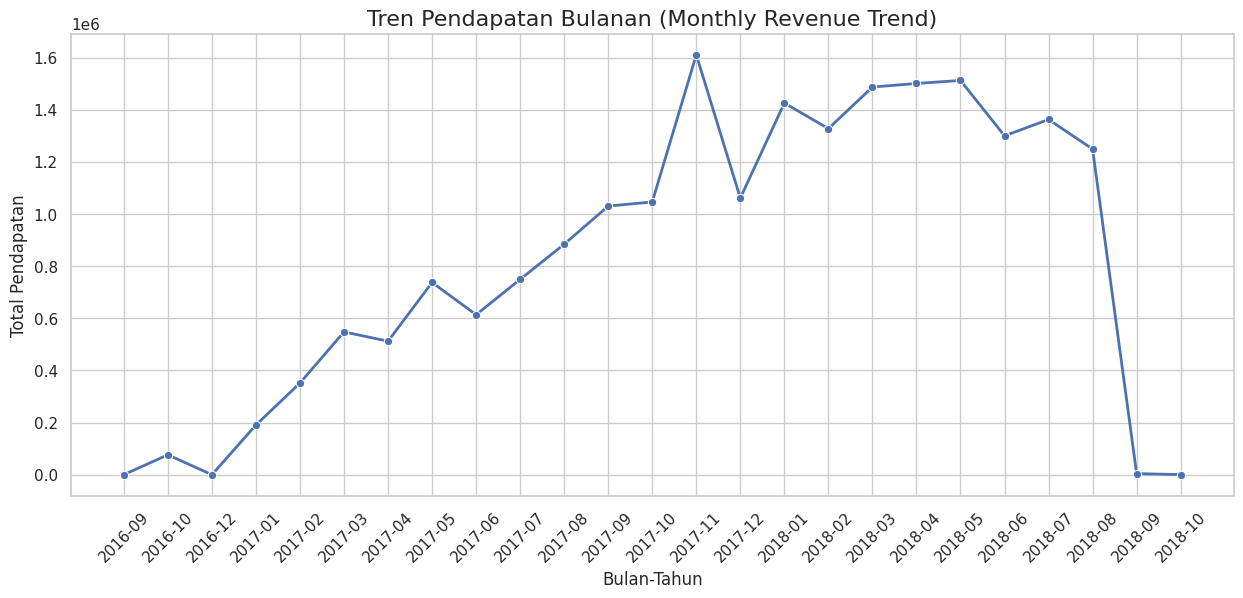


Total Keseluruhan Pendapatan: 20,579,664.01


In [ ]:
df_orders['year_month'] = df_orders['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = df_orders.groupby('year_month')['payment_value'].sum().reset_index()
monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_revenue, x='year_month', y='payment_value', marker='o', color='b', linewidth=2)
plt.title("Tren Pendapatan Bulanan (Monthly Revenue Trend)", fontsize=16)
plt.xlabel("Bulan-Tahun", fontsize=12)
plt.ylabel("Total Pendapatan", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

print(f"\nTotal Keseluruhan Pendapatan: {df_orders['payment_value'].sum():,.2f}")

**Top Profitable Product Categories (Analisis Kategori Produk Paling Menguntungkan)**

/tmp/ipykernel_1555/1102986914.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


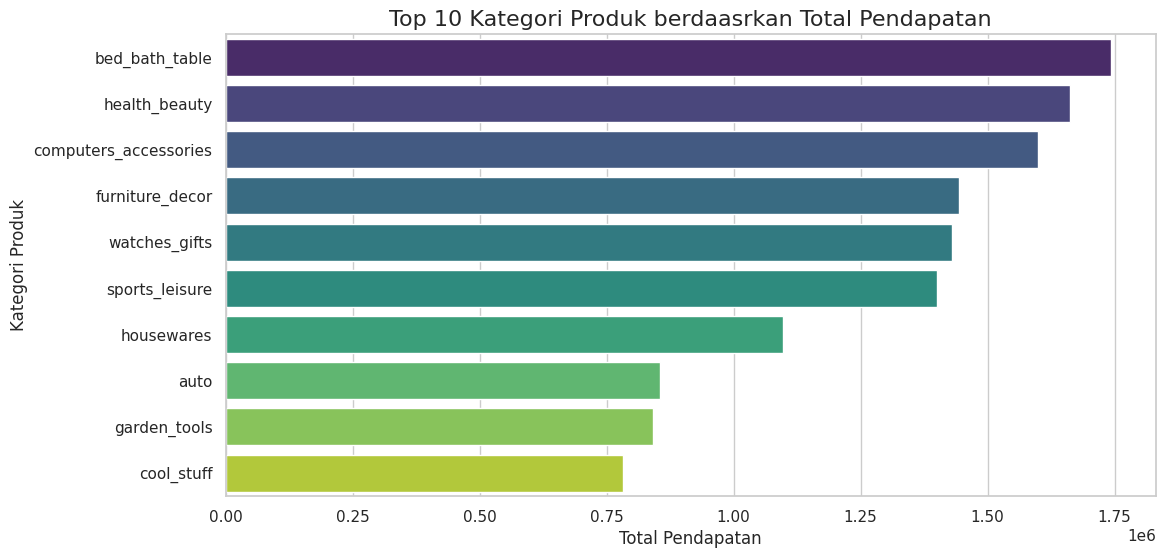

,payment_value
product_category_name_english,
bed_bath_table,1743998.80
health_beauty,1662963.59
computers_accessories,1599481.06
furniture_decor,1443963.61
watches_gifts,1430553.48
sports_leisure,1400223.07
housewares,1097900.09
auto,855095.68
garden_tools,840721.59


In [ ]:
top_categories =  df_orders.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title("Top 10 Kategori Produk berdaasrkan Total Pendapatan", fontsize=16)
plt.xlabel("Total Pendapatan", fontsize=12)
plt.ylabel("Kategori Produk", fontsize=12)
plt.show()

display(top_categories.head(10))

**Geospatial Analysis of Customers and Sellers (Analisis Geospasial Pelanggan & Penjual)**

/tmp/ipykernel_1555/933201937.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=customer_states.index, y=customer_states.values, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_1555/933201937.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seller_states.index, y=seller_states.values, ax=axes[1], palette='Oranges_r')


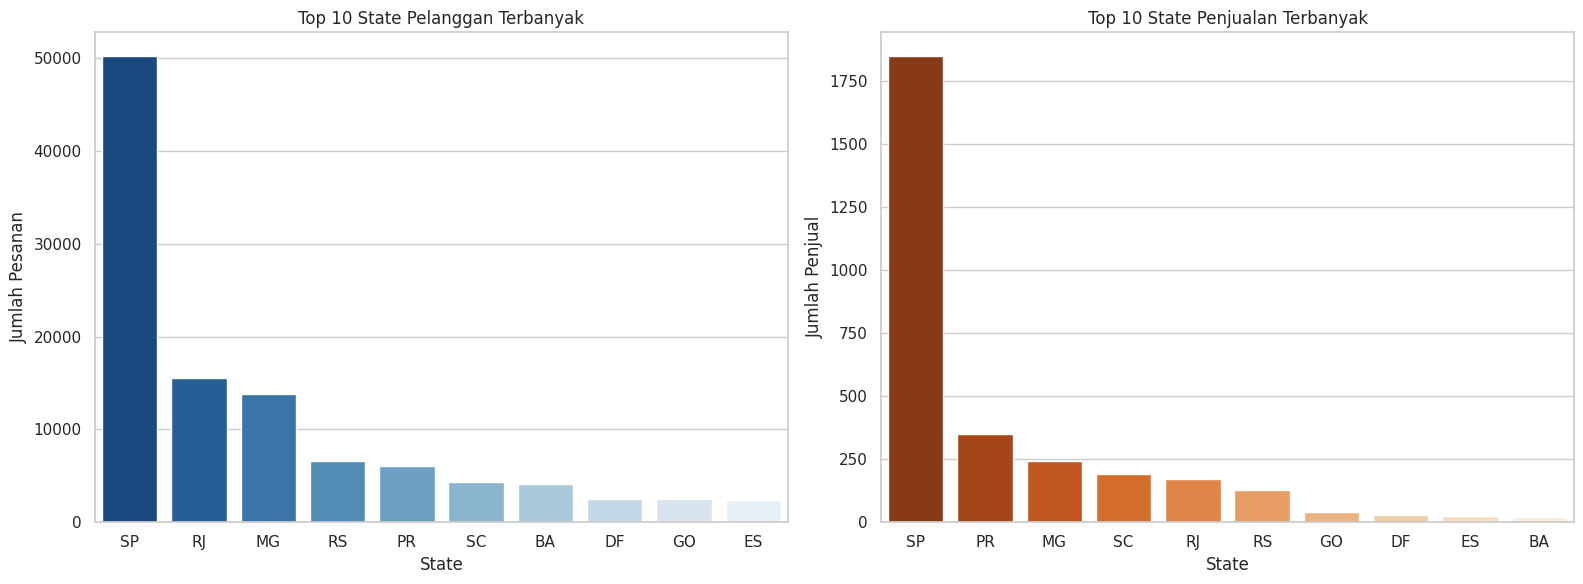

In [ ]:
customer_states = df_orders['customer_state'].value_counts().head(10)

seller_states = df_sallers['seller_state'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=customer_states.index, y=customer_states.values, ax=axes[0], palette='Blues_r')
axes[0].set_title("Top 10 State Pelanggan Terbanyak")
axes[0].set_ylabel("Jumlah Pesanan")
axes[0].set_xlabel("State")

sns.barplot(x=seller_states.index, y=seller_states.values, ax=axes[1], palette='Oranges_r')
axes[1].set_title("Top 10 State Penjualan Terbanyak")
axes[1].set_ylabel("Jumlah Penjual")
axes[1].set_xlabel("State")

plt.tight_layout()
plt.show()

**Customer Segmentation (RFM Analysis)**

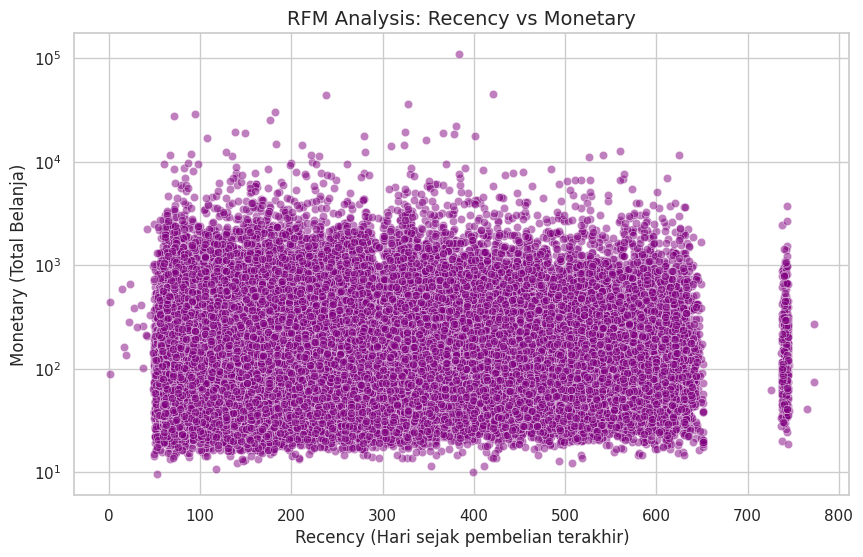

Jumlah Pelanggan Unik: 96,096
Top 5 RFM Segments:
 RFM_Segment
444    1806
344    1744
244    1717
232    1641
122    1620
Name: count, dtype: int64


In [ ]:
import datetime as dt

latest_date = df_orders['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm = df_orders.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (latest_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', alpha=0.5, color='purple')
plt.title("RFM Analysis: Recency vs Monetary", fontsize=14)
plt.xlabel("Recency (Hari sejak pembelian terakhir)")
plt.ylabel("Monetary (Total Belanja)")
plt.yscale('log')
plt.show()

print(f"Jumlah Pelanggan Unik: {rfm.shape[0]:,}")
print("Top 5 RFM Segments:\n", rfm['RFM_Segment'].value_counts().head(5))

**Logistics Performance & Customer Satisfaction (Korelasi Logistik & Review)**

/tmp/ipykernel_1555/124852657.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delivered_orders, x='review_score', y='delivery_time_days', palette='coolwarm')


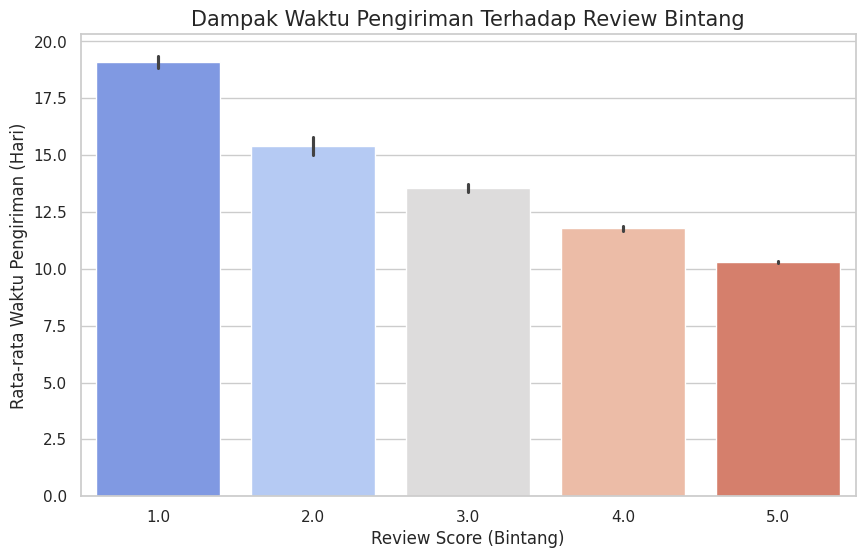


Median Persentase Ongkir terhadap Harga Produk per Bintang:
 review_score
1.0    24.371429
2.0    24.459103
3.0    24.613050
4.0    23.247496
5.0    22.671119
Name: freight_ratio, dtype: float64


In [ ]:
delivered_orders = df_orders[(df_orders['order_status'] == 'delivered') & (df_orders['order_delivered_customer_date'].notna())].copy()

delivered_orders['delivery_time_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']).dt.days

plt.figure(figsize=(10, 6))
sns.barplot(data=delivered_orders, x='review_score', y='delivery_time_days', palette='coolwarm')
plt.title("Dampak Waktu Pengiriman Terhadap Review Bintang", fontsize=15)
plt.xlabel("Review Score (Bintang)", fontsize=12)
plt.ylabel("Rata-rata Waktu Pengiriman (Hari)", fontsize=12)
plt.show()

delivered_orders['freight_ratio'] = (delivered_orders['freight_value'] / delivered_orders['price']) * 100
avg_freight_ratio = delivered_orders.groupby('review_score')['freight_ratio'].median()
print("\nMedian Persentase Ongkir terhadap Harga Produk per Bintang:\n", avg_freight_ratio)


**Logistics Density Map (Pemetaan Geospasial)**

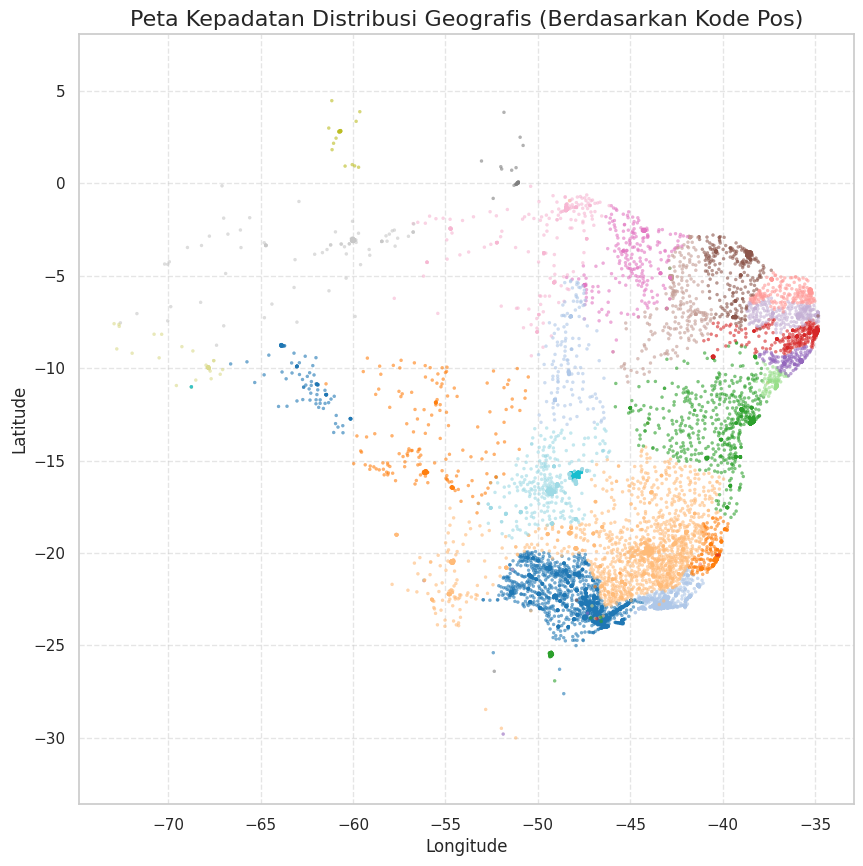

In [ ]:
geo_unique = df_geo.drop_duplicates(subset=['geolocation_zip_code_prefix']).copy()

brazil_geo = geo_unique[
    (geo_unique['geolocation_lat'] <= 5.274388) &
    (geo_unique['geolocation_lat'] >= -33.751169) &
    (geo_unique['geolocation_lng'] <= -34.793147) &
    (geo_unique['geolocation_lng'] >= -73.982830)
]

plt.figure(figsize=(10, 10))

sns.scatterplot(
    x='geolocation_lng',
    y='geolocation_lat',
    data=brazil_geo,
    hue='geolocation_state',
    palette='tab20',
    s=5,
    legend=False,
    edgecolor=None,
    alpha=0.6
)

plt.title("Peta Kepadatan Distribusi Geografis (Berdasarkan Kode Pos)", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("equal")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Financial & Payment Behavior (Analisis Perilaku Pembayaran)**

/tmp/ipykernel_1555/3476564917.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


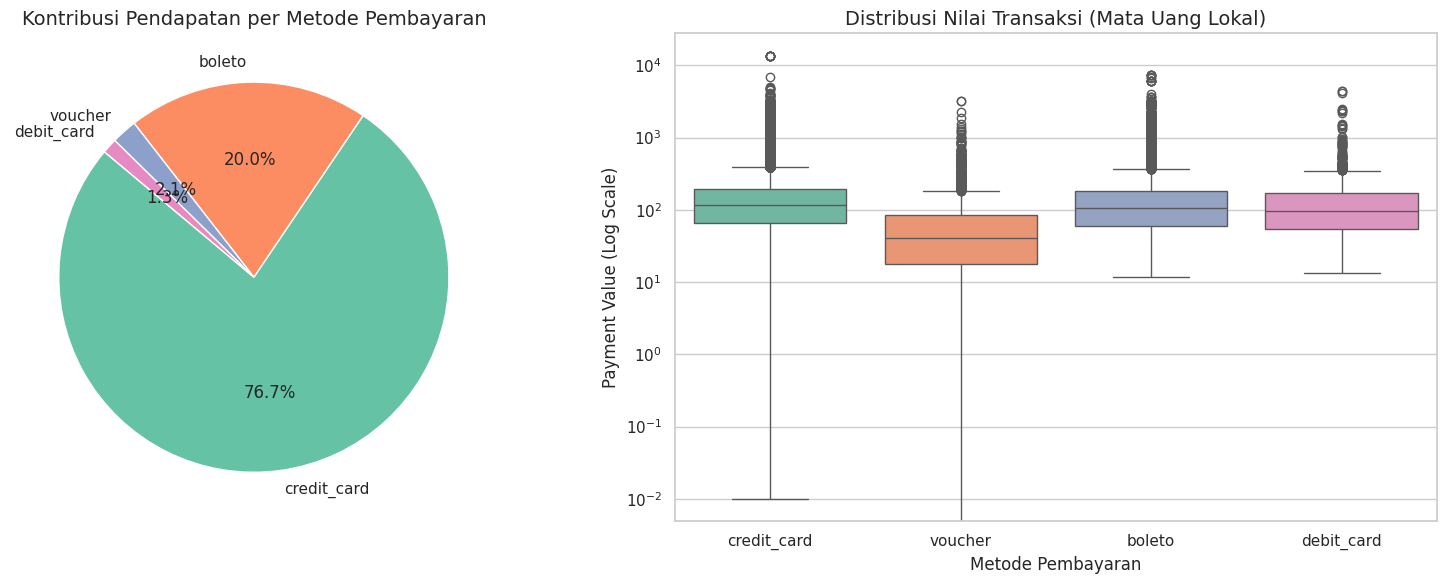

,payment_type,total_revenue,transaction_count,median_order_value
1,credit_card,15775450.54,87776,115.300
0,boleto,4110920.74,23190,105.980
3,voucher,435917.84,6465,40.110
2,debit_card,257374.89,1706,97.535


In [ ]:
from matplotlib import colors
from enum import auto
df_payment = df_orders[df_orders['payment_type'] != 'not_defined'].copy()

payment_summary = df_payment.groupby('payment_type').agg(
    total_revenue = ('payment_value', 'sum'),
    transaction_count = ('payment_value', 'count'),
    median_order_value = ('payment_value', 'median')
).reset_index().sort_values(by='total_revenue', ascending=False)

fig, axes =  plt.subplots(1, 2, figsize=(16, 6))

axes[0].pie(
    payment_summary['total_revenue'],
    labels = payment_summary['payment_type'],
    autopct = '%1.1f%%',
    startangle = 140,
    colors = sns.color_palette('Set2')
)
axes[0].set_title('Kontribusi Pendapatan per Metode Pembayaran', fontsize=14)

sns.boxplot(
    data=df_payment,
    x='payment_type',
    y='payment_value',
    ax=axes[1],
    palette="Set2"
)
axes[1].set_title('Distribusi Nilai Transaksi (Mata Uang Lokal)', fontsize=14)
axes[1].set_ylabel('Payment Value (Log Scale)')
axes[1].set_xlabel('Metode Pembayaran')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

display(payment_summary)

**Order Economics (Toleransi Ongkos Kirim terhadap Harga Barang)**

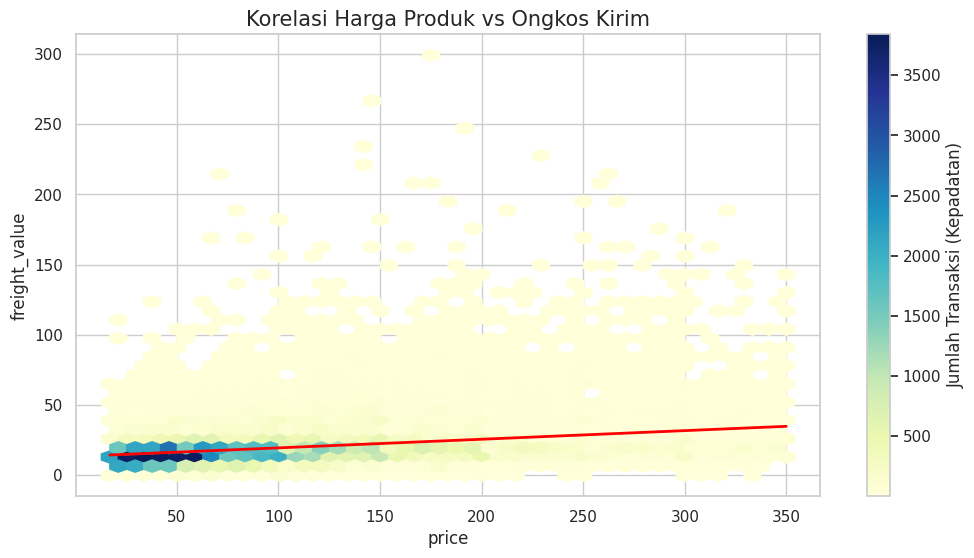

Rata-rata pelanggan membayar ongkir sebesar: 23.14% dari harga produk.


In [ ]:
q1_price = df_orders['price'].quantile(0.05)
q3_price = df_orders['price'].quantile(0.95)

filtered_economics = df_orders[
    (df_orders['price'] >= q1_price) &
    (df_orders['price'] <= q3_price)
].copy()

filtered_economics['freight_ratio_percent'] = (filtered_economics['freight_value'] / filtered_economics['price']) * 100

plt.figure(figsize=(12, 6))
plt.hexbin(
    x=filtered_economics['price'],
    y=filtered_economics['freight_value'],
    gridsize=40,
    cmap='YlGnBu',
    mincnt=1
)
cb = plt.colorbar(label='Jumlah Transaksi (Kepadatan)')
plt.title('Korelasi Harga Produk vs Ongkos Kirim', fontsize=15)
plt.xlabel('Harga Produk (Price)', fontsize=12)
plt.ylabel('Ongkos Kirim (Freight Value)', fontsize=12)

sns.regplot(
    x='price',
    y='freight_value',
    data=filtered_economics,
    scatter=False,
    color='red',
    line_kws={"linewidth": 2}
)
plt.show()

print(f"Rata-rata pelanggan membayar ongkir sebesar: {filtered_economics['freight_ratio_percent'].median():.2f}% dari harga produk.")